In [1]:
import pandas as pd
import numpy as np    

# 13. Corpus statistics

In [2]:
df = pd.read_json("/home/vitquay1708/Study_Space/NLP/lab2/c4-train.00000-of-01024-30K.json", lines=True)
corpus = df["text"]
corpus.head(5)

0    Beginners BBQ Class Taking Place in Missoula!\...
1    Discussion in 'Mac OS X Lion (10.7)' started b...
2    Foil plaid lycra and spandex shortall with met...
3    How many backlinks per day for new site?\nDisc...
4    The Denver Board of Education opened the 2017-...
Name: text, dtype: object

In [3]:
import nltk
nltk.download('punkt_tab')

/home/vitquay1708/miniconda3/envs/nlp/lib/python3.10/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/vitquay1708/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/vitquay1708/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
from nltk.tokenize import sent_tokenize, word_tokenize
from collections import Counter

num_documents = len(corpus)

all_sentences = []
all_tokens = []
for doc in corpus:
    sents = sent_tokenize(doc)
    all_sentences.extend(sents)
    for sent in sents:
        tokens = word_tokenize(sent.lower())
        all_tokens.extend(tokens)

num_sentences = len(all_sentences)

num_tokens = len(all_tokens)

vocab_size = len(set(all_tokens))

unigram_freq = Counter(all_tokens)
num_unigrams = len(unigram_freq)

bigrams = list(zip(all_tokens[:-1], all_tokens[1:]))
bigram_freq = Counter(bigrams)
num_bigrams = len(bigram_freq)

trigrams = list(zip(all_tokens[:-2], all_tokens[1:-1], all_tokens[2:]))
trigram_freq = Counter(trigrams)
num_trigrams = len(trigram_freq)

hapax_unigrams = sum(1 for c in unigram_freq.values() if c == 1)
hapax_bigrams = sum(1 for c in bigram_freq.values() if c == 1)
hapax_trigrams = sum(1 for c in trigram_freq.values() if c == 1)
total_hapax = hapax_unigrams + hapax_bigrams + hapax_trigrams

# In kết quả
print(f'Số documents:                {num_documents:,}')
print(f'Số sentences:                {num_sentences:,}')
print(f'Số tokens:                   {num_tokens:,}')
print(f'Vocabulary size:             {vocab_size:,}')
print(f'Số unigram (unique):         {num_unigrams:,}')
print(f'Số bigram (unique):          {num_bigrams:,}')
print(f'Số trigram (unique):         {num_trigrams:,}')
print(f'---')
print(f'Unigram xuất hiện 1 lần:     {hapax_unigrams:,}')
print(f'Bigram xuất hiện 1 lần:      {hapax_bigrams:,}')
print(f'Trigram xuất hiện 1 lần:     {hapax_trigrams:,}')
print(f'Tổng n-gram xuất hiện 1 lần: {total_hapax:,}')

Số documents:                30,000
Số sentences:                622,194
Số tokens:                   12,459,342
Vocabulary size:             259,813
Số unigram (unique):         259,813
Số bigram (unique):          2,875,278
Số trigram (unique):         7,679,362
---
Unigram xuất hiện 1 lần:     146,246
Bigram xuất hiện 1 lần:      2,012,659
Trigram xuất hiện 1 lần:     6,521,490
Tổng n-gram xuất hiện 1 lần: 8,680,395


## Top 30 Frequency của Unigram/Bigram/Trigram

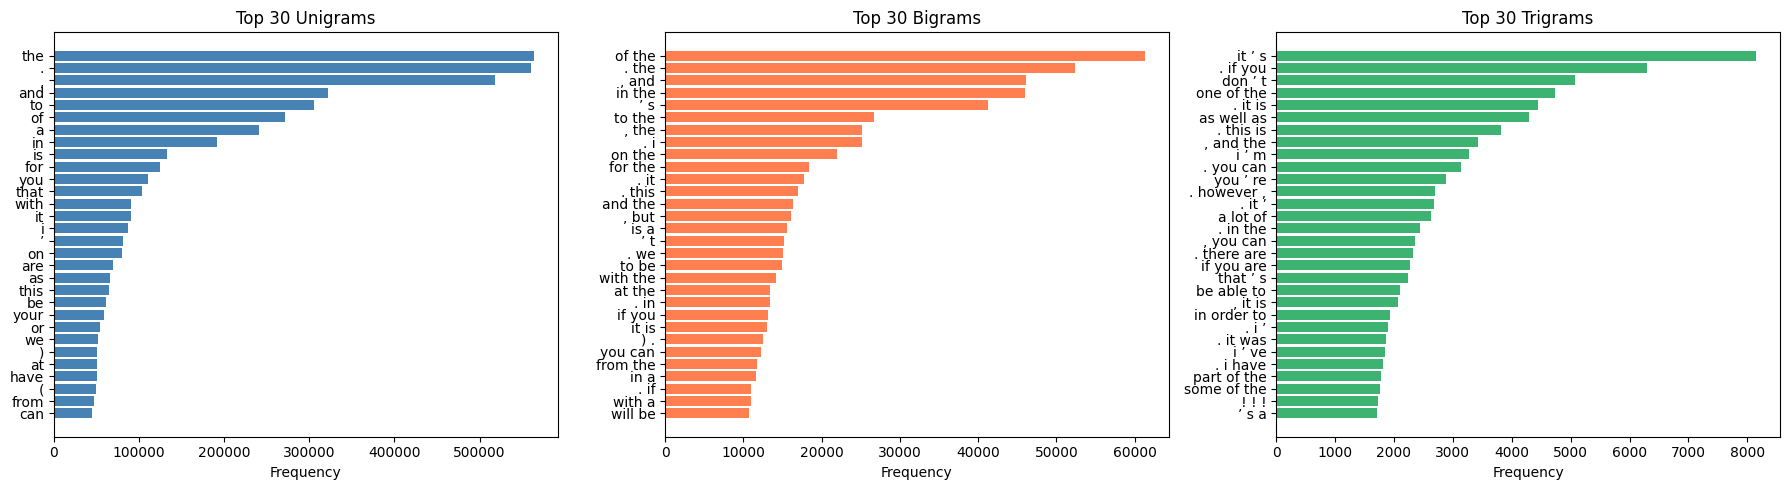

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Unigram frequency (top 30)
top_unigrams = unigram_freq.most_common(30)
words, counts = zip(*top_unigrams)
axes[0].barh(range(len(words)), counts, color='steelblue')
axes[0].set_yticks(range(len(words)))
axes[0].set_yticklabels(words)
axes[0].invert_yaxis()
axes[0].set_xlabel('Frequency')
axes[0].set_title('Top 30 Unigrams')

# Bigram frequency (top 30)
top_bigrams = bigram_freq.most_common(30)
labels, counts = zip(*top_bigrams)
labels = [f'{a} {b}' for a, b in labels]
axes[1].barh(range(len(labels)), counts, color='coral')
axes[1].set_yticks(range(len(labels)))
axes[1].set_yticklabels(labels)
axes[1].invert_yaxis()
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 30 Bigrams')

# Trigram frequency (top 30)
top_trigrams = trigram_freq.most_common(30)
labels, counts = zip(*top_trigrams)
labels = [f'{a} {b} {c}' for a, b, c in labels]
axes[2].barh(range(len(labels)), counts, color='mediumseagreen')
axes[2].set_yticks(range(len(labels)))
axes[2].set_yticklabels(labels)
axes[2].invert_yaxis()
axes[2].set_xlabel('Frequency')
axes[2].set_title('Top 30 Trigrams')

plt.tight_layout()
plt.show()

# Split train, test, validation trên corpus

In [6]:
from sklearn.model_selection import train_test_split
train_corpus, temp_corpus = train_test_split(corpus, test_size=0.2, random_state=42)
val_corpus, test_corpus = train_test_split(temp_corpus, test_size=0.5, random_state=42)

print(f'Train:      {len(train_corpus):,} documents ({len(train_corpus)/len(corpus)*100:.0f}%)')
print(f'Validation: {len(val_corpus):,} documents ({len(val_corpus)/len(corpus)*100:.0f}%)')
print(f'Test:       {len(test_corpus):,} documents ({len(test_corpus)/len(corpus)*100:.0f}%)')

Train:      24,000 documents (80%)
Validation: 3,000 documents (10%)
Test:       3,000 documents (10%)


## Experiment 2: So sánh MLE và smoothing

In [ ]:
import sys
sys.path.insert(0, '/home/vitquay1708/Study_Space/NLP/lab2')
from NGramLanguageModel import NGramLanguageModel

# Hàm tính average perplexity trên tập documents
def avg_perplexity(model, documents):
    ppls = []
    for doc in documents:
        ppl = model.perplexity(doc)
        if not np.isinf(ppl):
            ppls.append(ppl)
    return np.mean(ppls) if ppls else float('inf')

# Khởi tạo 4 models
models = {
    'Bigram MLE':     NGramLanguageModel(n=2, smoothing=False),
    'Bigram Laplace': NGramLanguageModel(n=2, smoothing=True),
    'Trigram MLE':    NGramLanguageModel(n=3, smoothing=False),
    'Trigram Laplace':NGramLanguageModel(n=3, smoothing=True),
}


In [ ]:
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(train_corpus)
print('Done!\n')
# Tính Perplexity trên train / validation / test
results = []
for name, model in models.items():
    print(f'Evaluating {name}...')
    train_ppl = avg_perplexity(model, train_corpus)
    val_ppl   = avg_perplexity(model, val_corpus)
    test_ppl  = avg_perplexity(model, test_corpus)
    results.append({
        'Model': name,
        'Train PPL': round(train_ppl, 2),
        'Valid PPL': round(val_ppl, 2),
        'Test PPL':  round(test_ppl, 2),
    })

Training Bigram MLE...
Training Bigram Laplace...
Training Trigram MLE...


In [ ]:
results_df = pd.DataFrame(results)
print('\n')
print(results_df.to_string(index=False))
results_df

# Experiment 3: Perplexity